In [4]:
!pip install -q mlflow
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import math
import os
import shutil
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight

from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
DOSSIER_MLFLOW_LOCAL = "/content/mlflow"
DOSSIER_MLFLOW_DRIVE = f"{DOSSIER}/mlflow"
if os.path.exists(DOSSIER_MLFLOW_DRIVE) and not os.path.exists(DOSSIER_MLFLOW_LOCAL):
    shutil.copytree(DOSSIER_MLFLOW_DRIVE, DOSSIER_MLFLOW_LOCAL)
if os.path.exists(f"{DOSSIER}/mlruns") and not os.path.exists("/content/mlruns"):
    shutil.copytree(f"{DOSSIER}/mlruns", "/content/mlruns")
os.makedirs(DOSSIER_MLFLOW_LOCAL, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{DOSSIER_MLFLOW_LOCAL}/mlflow.db")

vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")
imputeur = SimpleImputer(strategy="median").fit(X_train)
Xa_train = imputeur.transform(X_train).astype("float32")
Xa_val = imputeur.transform(X_val).astype("float32")
ya_train = y_train.to_numpy().astype("float32")
ya_val = y_val.to_numpy().astype("float32")
infos_val = vols.loc[X_val.index, ["moteur", "cycle", "RUL"]]
poids_classes = dict(enumerate(
    compute_class_weight("balanced", classes=np.array([0, 1]), y=ya_train.astype(int))
))

print("TensorFlow", tf.__version__, "| GPU :", tf.config.list_physical_devices("GPU"))
print("Train :", Xa_train.shape, "| Validation :", Xa_val.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow 2.21.0 | GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Train : (3716, 126) | Validation : (819, 126)


In [4]:
from aeroguard.metier import evaluer_alerte
from aeroguard.modeles import seuil_optimal
from aeroguard.reseaux import creer_callbacks, creer_normaliseur, creer_reseau_dense

CONFIGURATIONS = {
    "A_sans_protection":   {"taux_dropout": 0.0, "callbacks": False, "epoques": 60},
    "B_dropout":           {"taux_dropout": 0.3, "callbacks": False, "epoques": 60},
    "C_callbacks":         {"taux_dropout": 0.0, "callbacks": True,  "epoques": 300},
    "D_dropout_callbacks": {"taux_dropout": 0.3, "callbacks": True,  "epoques": 300},
}
GRAINES = [42, 1, 2]
os.makedirs("/content/checkpoints", exist_ok=True)


def scores_numeriques(scores):
    """Garde seulement les nombres valides (MLflow refuse le texte et les NaN)."""
    propres = {}
    for cle, valeur in scores.items():
        try:
            nombre = float(valeur)
        except (TypeError, ValueError):
            continue
        if not math.isnan(nombre):
            propres[cle] = nombre
    return propres


def entrainer_configuration(nom, reglages, graine):
    """Entraîne un réseau, puis l'évalue par vol et par moteur sur la validation."""
    reseau = creer_reseau_dense(
        Xa_train.shape[1],
        normaliseur=creer_normaliseur(Xa_train),
        taux_dropout=reglages["taux_dropout"],
        graine=graine,
    )
    chemin = f"/content/checkpoints/{nom}_{graine}.keras"
    callbacks = creer_callbacks(chemin, patience=10) if reglages["callbacks"] else []

    debut = time.perf_counter()
    historique = reseau.fit(
        Xa_train, ya_train,
        validation_data=(Xa_val, ya_val),
        epochs=reglages["epoques"],
        batch_size=64,
        class_weight=poids_classes,
        callbacks=callbacks,
        verbose=0,
    )
    duree = time.perf_counter() - debut

    courbes = pd.DataFrame(historique.history)
    courbes.index += 1
    probas = reseau.predict(Xa_val, verbose=0).ravel()
    seuil, _ = seuil_optimal(ya_val.astype(int), probas)
    scores = evaluer_alerte(y_val, probas, seuil, infos_val, k=3, col_moteur="moteur")

    resume = {
        "configuration": nom,
        "graine": graine,
        "epoques_faites": len(courbes),
        "meilleure_epoque": int(courbes["val_loss"].idxmin()),
        "val_loss_min": courbes["val_loss"].min(),
        "seuil": seuil,
        "duree_s": duree,
        **scores,
    }
    return reseau, courbes, resume

In [5]:
mlflow.set_experiment("aeroguard-alerte")
resultats = []
courbes_graine_42 = {}
modeles_graine_42 = {}

with mlflow.start_run(run_name="lecon_44_surapprentissage"):
    mlflow.set_tags({"lecon": "4.4", "tache": "alerte", "jeu": "validation"})
    for nom, reglages in CONFIGURATIONS.items():
        for graine in GRAINES:
            reseau, courbes, resume = entrainer_configuration(nom, reglages, graine)
            resultats.append(resume)
            if graine == 42:
                courbes_graine_42[nom] = courbes
                modeles_graine_42[nom] = reseau
            with mlflow.start_run(run_name=f"{nom}_graine_{graine}", nested=True):
                mlflow.log_params({
                    "configuration": nom,
                    "architecture": "126-64-32-1",
                    "taux_dropout": reglages["taux_dropout"],
                    "callbacks": reglages["callbacks"],
                    "epoques_max": reglages["epoques"],
                    "graine": graine,
                    "seuil": round(resume["seuil"], 2),
                })
                mlflow.log_metrics(scores_numeriques(resume))
            print(f"{nom:22s} graine {graine:2d} → {resume['epoques_faites']:3d} époques, "
                  f"meilleure {resume['meilleure_epoque']:3d}, F1 macro {resume['f1_macro']:.3f}")

A_sans_protection      graine 42 →  60 époques, meilleure  17, F1 macro 0.872
A_sans_protection      graine  1 →  60 époques, meilleure  14, F1 macro 0.882
A_sans_protection      graine  2 →  60 époques, meilleure  19, F1 macro 0.880
B_dropout              graine 42 →  60 époques, meilleure  38, F1 macro 0.881
B_dropout              graine  1 →  60 époques, meilleure  33, F1 macro 0.866
B_dropout              graine  2 →  60 époques, meilleure  30, F1 macro 0.894
C_callbacks            graine 42 →  41 époques, meilleure  31, F1 macro 0.872
C_callbacks            graine  1 →  24 époques, meilleure  14, F1 macro 0.873
C_callbacks            graine  2 →  29 époques, meilleure  19, F1 macro 0.873
D_dropout_callbacks    graine 42 →  44 époques, meilleure  34, F1 macro 0.872
D_dropout_callbacks    graine  1 →  45 époques, meilleure  35, F1 macro 0.872
D_dropout_callbacks    graine  2 →  51 époques, meilleure  41, F1 macro 0.886


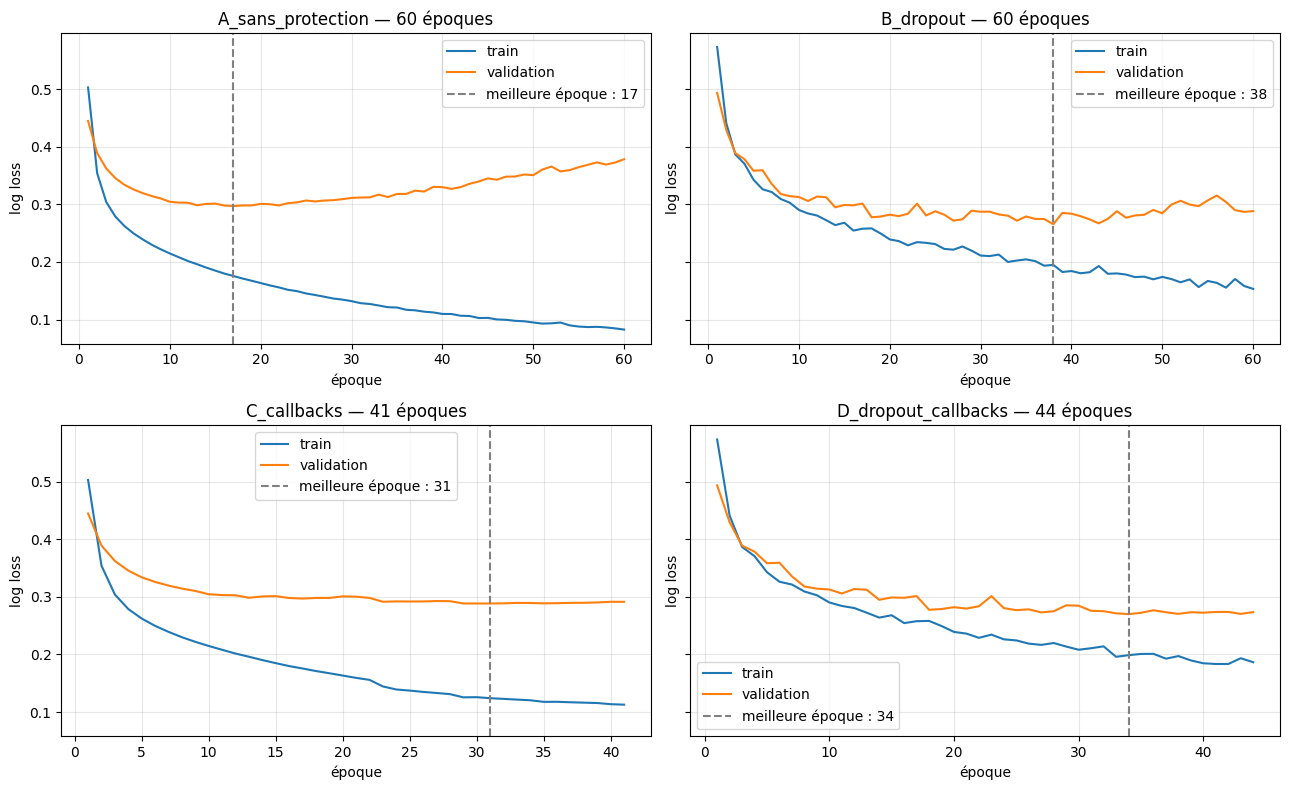

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for axe, (nom, courbes) in zip(axes.ravel(), courbes_graine_42.items()):
    meilleure = int(courbes["val_loss"].idxmin())
    axe.plot(courbes.index, courbes["loss"], label="train")
    axe.plot(courbes.index, courbes["val_loss"], label="validation")
    axe.axvline(meilleure, color="gray", linestyle="--", label=f"meilleure époque : {meilleure}")
    axe.set_title(f"{nom} — {len(courbes)} époques")
    axe.set_xlabel("époque")
    axe.set_ylabel("log loss")
    axe.grid(alpha=0.3)
    axe.legend()
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/44_courbes_protection.png", dpi=150)
plt.show()

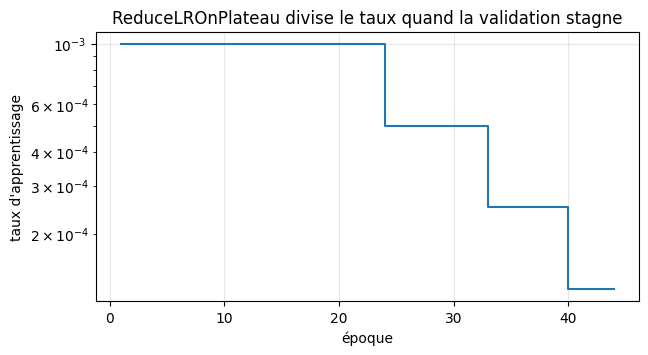

1     0.001000
24    0.000500
33    0.000250
40    0.000125
Name: learning_rate, dtype: float64


In [7]:
courbes_d = courbes_graine_42["D_dropout_callbacks"]
if "learning_rate" in courbes_d.columns:
    plt.figure(figsize=(7, 3.5))
    plt.step(courbes_d.index, courbes_d["learning_rate"], where="post")
    plt.yscale("log")
    plt.xlabel("époque")
    plt.ylabel("taux d'apprentissage")
    plt.title("ReduceLROnPlateau divise le taux quand la validation stagne")
    plt.grid(alpha=0.3)
    plt.show()
    print(courbes_d["learning_rate"].drop_duplicates())
else:
    print("Le taux n'est pas enregistré dans l'historique avec cette version de Keras.")

In [8]:
tableau = pd.DataFrame(resultats)
synthese = tableau.groupby("configuration").agg(
    epoques=("epoques_faites", "mean"),
    meilleure_epoque=("meilleure_epoque", "mean"),
    val_loss_min=("val_loss_min", "mean"),
    f1_macro_moyen=("f1_macro", "mean"),
    f1_macro_ecart_type=("f1_macro", "std"),
    seuil_min=("seuil", "min"),
    seuil_max=("seuil", "max"),
    fausses_alarmes=("fausses_alarmes_total", "mean"),
    avance_moyenne=("avance_moyenne", "mean"),
    duree_s=("duree_s", "mean"),
)
synthese.round(3)

,epoques,meilleure_epoque,val_loss_min,f1_macro_moyen,f1_macro_ecart_type,seuil_min,seuil_max,fausses_alarmes,avance_moyenne,duree_s
configuration,,,,,,,,,,
A_sans_protection,60.000,16.667,0.290,0.878,0.005,0.39,0.69,4.000,46.121,25.057
B_dropout,60.000,33.667,0.272,0.880,0.014,0.36,0.50,5.667,44.697,26.315
C_callbacks,31.333,21.333,0.287,0.873,0.001,0.30,0.58,5.000,44.848,16.249
D_dropout_callbacks,46.667,36.667,0.274,0.877,0.008,0.36,0.51,3.667,43.394,22.377


In [9]:
CHEMIN_MODELE = f"{DOSSIER}/models/reseau_dense_regularise_v4.keras"
modeles_graine_42["D_dropout_callbacks"].save(CHEMIN_MODELE)
print("✅ Modèle sauvegardé :", CHEMIN_MODELE)

print("\nPour comparaison (validation, leçon D3) : XGBoost 0,887 — logistique 0,894")
print(f"Réseau protégé (D), moyenne sur 3 graines : "
      f"{synthese.loc['D_dropout_callbacks', 'f1_macro_moyen']:.3f}")

✅ Modèle sauvegardé : /content/drive/MyDrive/aeroguard/models/reseau_dense_regularise_v4.keras

Pour comparaison (validation, leçon D3) : XGBoost 0,887 — logistique 0,894
Réseau protégé (D), moyenne sur 3 graines : 0.877


In [10]:
dossiers_artifacts = set()
for experience in mlflow.search_experiments():
    emplacement = experience.artifact_location.replace("file://", "")
    if emplacement.startswith("/content") and not emplacement.startswith("/content/drive"):
        dossiers_artifacts.add(os.path.dirname(emplacement))

shutil.copytree(DOSSIER_MLFLOW_LOCAL, DOSSIER_MLFLOW_DRIVE, dirs_exist_ok=True)
for dossier in dossiers_artifacts:
    if os.path.exists(dossier):
        shutil.copytree(dossier, f"{DOSSIER}/{os.path.basename(dossier)}", dirs_exist_ok=True)
print("✅ MLflow sauvegardé sur Drive")

✅ MLflow sauvegardé sur Drive
